## Analyse exploratoire des données (EDA)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataSet = pd.read_csv("dataset_reseau.csv")

In [5]:
dataSet.head()

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
0,M1381,linux,124.841713,80,464.209300,success
1,M996,linux,203.399243,212,696.590874,Succes
2,M1411,macos,71.099503,213,430.462099,Success
3,M1448,windows,150.118079,216,341.491727,Fail
4,M1448,Andriod,182.837035,79,259.873768,Succes


In [6]:
dataSet.tail()

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
10195,M1331,MacOS,152.549519,280,519.291287,fail
10196,M830,macos,78.707837,154,748.516228,success
10197,M8,linux,109.976522,197,530.399940,Succes
10198,M1248,windows,105.207239,250,684.211355,Success
10199,M1275,Linus,154.154944,153,366.478292,Succes


In [8]:
dataSet.shape

(10200, 6)

In [9]:
dataSet.dtypes

machine_id           object
os_type              object
duree_connexion     float64
nombre_requetes       int64
volume_donnees      float64
statut_connexion     object
dtype: object

In [10]:
dataSet.columns

Index(['machine_id', 'os_type', 'duree_connexion', 'nombre_requetes',
       'volume_donnees', 'statut_connexion'],
      dtype='object')

In [11]:
dataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   machine_id        10200 non-null  object 
 1   os_type           10200 non-null  object 
 2   duree_connexion   9667 non-null   float64
 3   nombre_requetes   10200 non-null  int64  
 4   volume_donnees    9699 non-null   float64
 5   statut_connexion  10200 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 478.3+ KB


In [14]:
dataSet.isnull().sum()

machine_id            0
os_type               0
duree_connexion     533
nombre_requetes       0
volume_donnees      501
statut_connexion      0
dtype: int64

In [15]:
dataSet.isnull().sum().sum()

1034

In [16]:
dataSet.duplicated().sum()

200

In [31]:
cat_columns = dataSet.select_dtypes(include=['object']).columns
for col in cat_columns:
    print(dataSet[col].value_counts())

machine_id
M200     16
M514     16
M1246    16
M168     15
M827     15
         ..
M335      1
M696      1
M1062     1
M25       1
M235      1
Name: count, Length: 1497, dtype: int64
os_type
Linus      1054
MacOS      1046
windows    1041
Linux      1023
Andriod    1020
Windows    1019
linux      1010
windos     1007
Android    1001
macos       979
Name: count, dtype: int64
statut_connexion
Failed     1746
Fail       1701
Succes     1699
Success    1694
success    1688
fail       1672
Name: count, dtype: int64


In [17]:
dataSet.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,9667.000000,10200.000000,9699.000000
mean,137.750628,199.042451,573.192602
std,125.556422,60.617558,557.366581
min,-25.753534,-24.000000,-43.984643
25%,93.851389,157.000000,399.976673
50%,120.775692,200.000000,502.638632
75%,149.055586,240.000000,608.036373
max,1197.000000,407.000000,5978.000000


In [20]:
dataSet.skew(numeric_only=True)

duree_connexion    5.866801
nombre_requetes   -0.017982
volume_donnees     6.791914
dtype: float64

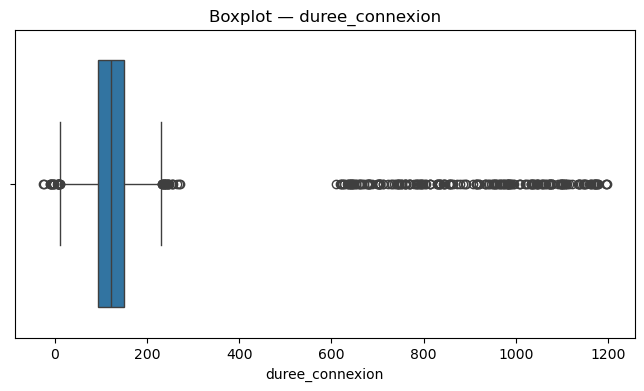

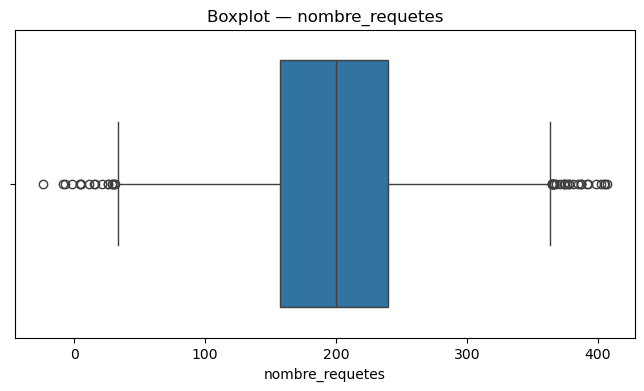

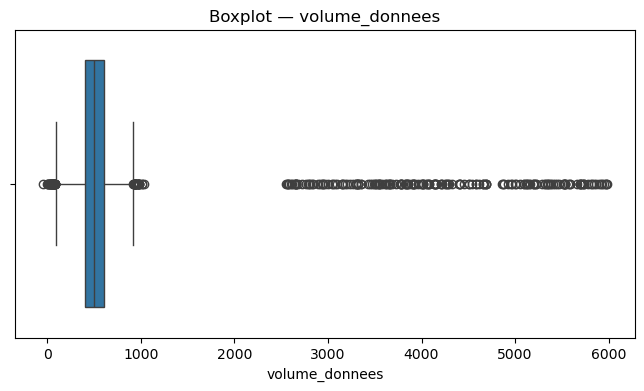

In [51]:
num_cols = dataSet.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataSet[col])
    plt.title(f"Boxplot — {col}")
    plt.show()

In [65]:
dataSet.drop_duplicates(inplace=True)

In [53]:
dataSet["os_type"] = dataSet["os_type"].replace({
    "Linus": "Linux",
    "linux": "Linux",
    "macos": "MacOS",
    "windows": "Windows",
    "windos": "Windows",
    "Andriod": "Android"
})
dataSet["statut_connexion"] = dataSet["statut_connexion"].replace({
    "Failed" : "fail",   
    "Fail" : "fail",
    "Succes" : "success",
    "Success" : "success"
})

In [67]:
cat_columns = dataSet.select_dtypes(include=['object']).columns
for col in cat_columns:
    print(dataSet[col].value_counts())

machine_id
M514     16
M200     16
M827     15
M32      15
M1246    15
         ..
M151      1
M335      1
M25       1
M82       1
M235      1
Name: count, Length: 1497, dtype: int64
os_type
Linux      3029
Windows    3021
Android    1979
MacOS      1971
Name: count, dtype: int64
statut_connexion
fail       5034
success    4966
Name: count, dtype: int64


In [68]:
num_cols = dataSet.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    dataSet[col] = dataSet[col].fillna(dataSet[col].median())

cat_cols = dataSet.select_dtypes(include=['object']).columns
for col in cat_cols:
    dataSet[col] = dataSet[col].fillna(dataSet[col].mode()[0])


In [57]:
num_cols = dataSet.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    
    Q1 = dataSet[col].quantile(0.25)
    Q3 = dataSet[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    borne_min = Q1 - 1.5 * IQR
    borne_max = Q3 + 1.5 * IQR
    
    outliers = dataSet[
        (dataSet[col] < borne_min) | 
        (dataSet[col] > borne_max)
    ].shape[0]
    print(f"{col} → {outliers} outliers détectés")
    print(f"   Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"   borne_min={borne_min:.2f} | borne_max={borne_max:.2f}")
    
    mediane = dataSet[col].median()
    
    dataSet.loc[dataSet[col] < borne_min, col] = mediane
    dataSet.loc[dataSet[col] > borne_max, col] = mediane

duree_connexion → 304 outliers détectés
   Q1=95.66 | Q3=147.53 | IQR=51.87
   borne_min=17.85 | borne_max=225.33
nombre_requetes → 46 outliers détectés
   Q1=157.00 | Q3=240.00 | IQR=83.00
   borne_min=32.50 | borne_max=364.50
volume_donnees → 289 outliers détectés
   Q1=405.41 | Q3=601.44 | IQR=196.02
   borne_min=111.38 | borne_max=895.47


In [58]:
dataSet.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,10200.000000,10200.000000,10200.000000
mean,120.106922,198.876961,500.262161
std,36.534923,59.347148,139.282850
min,18.026468,33.000000,112.902668
25%,96.196803,158.000000,408.516750
50%,120.775692,200.000000,502.638632
75%,144.195449,240.000000,589.622657
max,225.262332,364.000000,892.508398


In [69]:
dataSet.to_csv("dataset_reseau_clean.csv", index=False)